# Data Preprocessing - VKontakte Users vs Bots Classification


## 1. Setup & Configuration

In [95]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import joblib

# Configuration
pd.set_option('display.max_columns', 100)
plt.style.use('ggplot')
sns.set_palette('pastel')
%matplotlib inline

## 2. Data Loading

In [96]:
# Load dataset
raw_data_path = '../data/raw/bots_vs_users.csv'
df = pd.read_csv(raw_data_path)
print("Initial shape:", df.shape)

Initial shape: (5874, 60)


## 3. Data Cleaning

### 3.1 Remove Duplicates

In [97]:
print("Initial duplicates:", df.duplicated().sum())
df = df.drop_duplicates()
print("Remaining samples after deduplication:", df.shape[0])

Initial duplicates: 2616
Remaining samples after deduplication: 3258


In [98]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

=== Class Distribution ===


target
0    77.409454
1    22.590546
Name: proportion, dtype: float64

=== Number of samples per class ===
Bots: 736
Genuine Users: 2522


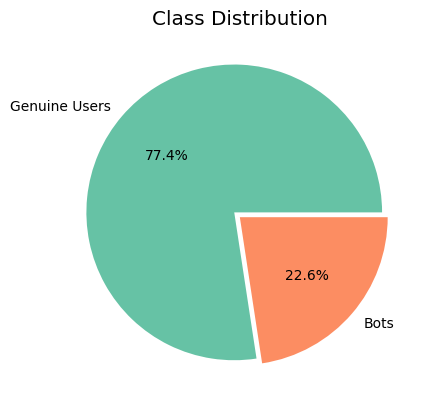

In [99]:
# get the destrebution of the target variable after deduplication
target_col = 'target'

print("=== Class Distribution ===")
class_dist = df[target_col].value_counts(normalize=True).mul(100)
display(class_dist)

print("=== Number of samples per class ===")
bot_count = df[target_col].value_counts()
print("Bots:", bot_count[1])
print("Genuine Users:", bot_count[0])


# Visualization
plt.pie(class_dist, 
        labels=['Genuine Users', 'Bots'],
        autopct='%1.1f%%',
        colors=['#66c2a5', '#fc8d62'],
        explode=(0.05, 0))
plt.title('Class Distribution')
plt.show()

### 3.2 Missing Value Treatment

In [100]:
# Drop columns that only has NaN values
all_nan_cols = df.columns[df.isna().all()]
print("Columns with all NaN values:", all_nan_cols.tolist())
df = df.drop(columns=all_nan_cols)

Columns with all NaN values: []


In [101]:
# Identify numerical features with >70% missing values
num_cols = X.select_dtypes(include=np.number).columns.tolist()
high_missing_num = [col for col in num_cols if X[col].isna().mean() > 0.7]
print("Numerical features with >70% missing values:", high_missing_num)

Numerical features with >70% missing values: []


In [102]:
# Create missing indicators
for col in high_missing_num:
    X[f'{col}_missing'] = X[col].isna().astype(int)
    

In [103]:
# Median imputation
num_imputer = SimpleImputer(strategy='median') # this SimpleImputer from sklearn will be used to fill in the missing values for numerical columns 
X[num_cols] = num_imputer.fit_transform(X[num_cols])

**Categorical Features Strategy**:
- Preserve 'unknown' category
- Handle rare categories

In [104]:
cat_cols = X.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

Categorical columns: ['has_domain', 'has_birth_date', 'has_photo', 'can_post_on_wall', 'can_send_message', 'has_website', 'gender', 'has_short_name', 'has_first_name', 'has_last_name', 'access_to_closed_profile', 'is_profile_closed', 'has_nickname', 'has_maiden_name', 'has_mobile', 'all_posts_visible', 'audio_available', 'has_interests', 'has_books', 'has_tv', 'has_quotes', 'has_about', 'has_games', 'has_movies', 'has_activities', 'has_music', 'can_add_as_friend', 'can_invite_to_group', 'subscribers_count', 'is_blacklisted', 'has_career', 'has_military_service', 'has_hometown', 'marital_status', 'has_universities', 'has_schools', 'has_relatives', 'is_verified', 'is_confirmed', 'has_status', 'city', 'has_occupation', 'occupation_type_university', 'occupation_type_work', 'has_personal_data']


In [105]:
print("=== Categorical columns before consolidation ===")
print(X[cat_cols].nunique())


=== Categorical columns before consolidation ===
has_domain                       2
has_birth_date                   2
has_photo                        3
can_post_on_wall                 3
can_send_message                 3
has_website                      3
gender                           4
has_short_name                   2
has_first_name                   2
has_last_name                    3
access_to_closed_profile         3
is_profile_closed                3
has_nickname                     3
has_maiden_name                  3
has_mobile                       3
all_posts_visible                3
audio_available                  3
has_interests                    3
has_books                        3
has_tv                           3
has_quotes                       3
has_about                        3
has_games                        3
has_movies                       3
has_activities                   3
has_music                        3
can_add_as_friend                3
can_in

In [106]:
# Consolidate rare categories (<5%)
for col in cat_cols:
    freq = X[col].value_counts(normalize=True)
    rare_categories = freq[freq < 0.05].index
    X[col] = X[col].replace(rare_categories, 'Rare')

In [107]:
print("=== Categorical columns after consolidation ===")
print(X[cat_cols].nunique())

=== Categorical columns after consolidation ===
has_domain                    2
has_birth_date                2
has_photo                     3
can_post_on_wall              3
can_send_message              3
has_website                   3
gender                        3
has_short_name                2
has_first_name                2
has_last_name                 2
access_to_closed_profile      3
is_profile_closed             3
has_nickname                  3
has_maiden_name               3
has_mobile                    3
all_posts_visible             3
audio_available               3
has_interests                 3
has_books                     3
has_tv                        3
has_quotes                    3
has_about                     3
has_games                     3
has_movies                    3
has_activities                3
has_music                     3
can_add_as_friend             3
can_invite_to_group           3
subscribers_count             2
is_blacklisted          

## 4. Data Transformation

### 4.1 Categorical Encoding

In [108]:
# Split categorical features by cardinality
low_cardinality = [col for col in cat_cols if X[col].nunique() < 10]
high_cardinality = [col for col in cat_cols if X[col].nunique() >= 10]
print("Low cardinality columns:", low_cardinality)
print("High cardinality columns:", high_cardinality)

Low cardinality columns: ['has_domain', 'has_birth_date', 'has_photo', 'can_post_on_wall', 'can_send_message', 'has_website', 'gender', 'has_short_name', 'has_first_name', 'has_last_name', 'access_to_closed_profile', 'is_profile_closed', 'has_nickname', 'has_maiden_name', 'has_mobile', 'all_posts_visible', 'audio_available', 'has_interests', 'has_books', 'has_tv', 'has_quotes', 'has_about', 'has_games', 'has_movies', 'has_activities', 'has_music', 'can_add_as_friend', 'can_invite_to_group', 'subscribers_count', 'is_blacklisted', 'has_career', 'has_military_service', 'has_hometown', 'marital_status', 'has_universities', 'has_schools', 'has_relatives', 'is_verified', 'is_confirmed', 'has_status', 'city', 'has_occupation', 'occupation_type_university', 'occupation_type_work', 'has_personal_data']
High cardinality columns: []


In [109]:
# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('low_card', OneHotEncoder(handle_unknown='ignore'), low_cardinality),
        ('high_card', OneHotEncoder(handle_unknown='infrequent_if_exist', 
                                   max_categories=10), high_cardinality)
    ])

# Fit and transform
X_processed = preprocessor.fit_transform(X)

# Save preprocessing pipeline
#joblib.dump(preprocessor, 'preprocessing_pipeline.pkl')

### 4.2 Feature Scaling

In [110]:
# Already handled in ColumnTransformer via StandardScaler

## 5. Data Splitting

In [111]:
# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 2606 samples
Test set: 652 samples


In [112]:
# save the train and test sets
output_path = '../data/processed/'
X_train_df = pd.DataFrame(X_train)
X_test_df = pd.DataFrame(X_test)
y_train_df = pd.DataFrame(y_train, columns=['target'])
y_test_df = pd.DataFrame(y_test, columns=['target'])

X_train_df.to_csv(output_path + 'X_train.csv', index=False)
X_test_df.to_csv(output_path + 'X_test.csv', index=False)
y_train_df.to_csv(output_path + 'y_train.csv', index=False)
y_test_df.to_csv(output_path + 'y_test.csv', index=False)
print("Train and test sets saved successfully.")

Train and test sets saved successfully.


## 6. Advanced Processing (Zyada)

### 6.1 Feature Selection

In [113]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select top 50 features
selector = SelectKBest(score_func=f_classif, k=50)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

c:\Users\lemon\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [123] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\lemon\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [114]:
# save the train and test sets with feature selection
output_path = '../data/processed/selected/'

X_train_selected_df = pd.DataFrame(X_train_selected)
X_test_selected_df = pd.DataFrame(X_test_selected)
y_train_selected_df = pd.DataFrame(y_train, columns=['target'])
y_test_selected_df = pd.DataFrame(y_test, columns=['target'])

X_train_selected_df.to_csv(output_path + 'X_train_selected.csv', index=False)
X_test_selected_df.to_csv(output_path + 'X_test_selected.csv', index=False)
y_train_selected_df.to_csv(output_path + 'y_train_selected.csv', index=False)
y_test_selected_df.to_csv(output_path + 'y_test_selected.csv', index=False)
print("Train and test sets with feature selection saved successfully.")


Train and test sets with feature selection saved successfully.


### 6.2 Dimensionality Reduction

In [115]:
from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_selected)
X_test_pca = pca.transform(X_test_selected)

print(f"Reduced dimensions: {X_train_pca.shape[1]} components")

Reduced dimensions: 18 components


## 7. Data Validation

### 7.1 Processed Data Statistics

In [116]:
# Check class balance
print("\nClass distribution:")
print(pd.DataFrame({
    'Training': y_train.value_counts(normalize=True),
    'Test': y_test.value_counts(normalize=True)
}))


Class distribution:
        Training     Test
target                   
0       0.773983  0.77454
1       0.226017  0.22546


### 7.2 Feature Distribution Check

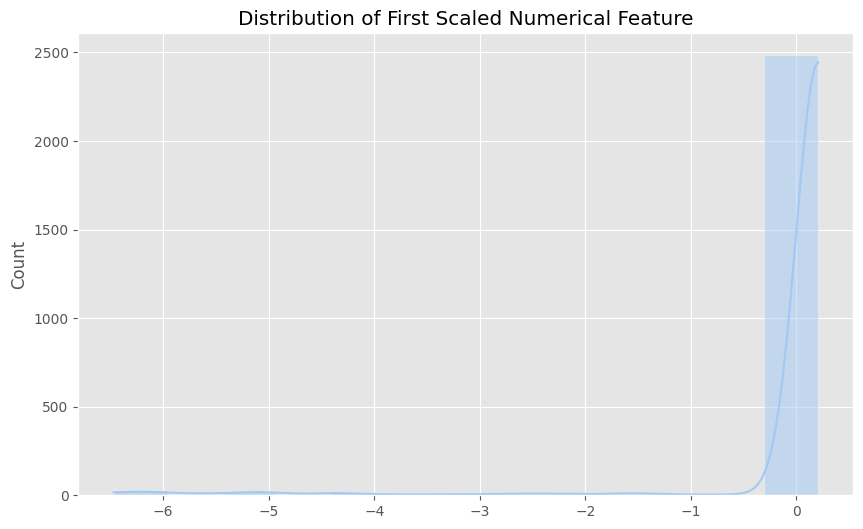

In [117]:
# Plot first numerical feature distribution
plt.figure(figsize=(10,6))
sns.histplot(X_train[:,0], kde=True)
plt.title('Distribution of First Scaled Numerical Feature')
plt.show()

## 8. Data Export

In [118]:
# Save processed data into CSV files
output_path = '../data/processed/pca/'

X_train_pca_df = pd.DataFrame(X_train_pca)
X_test_pca_df = pd.DataFrame(X_test_pca)
y_train_df = pd.DataFrame(y_train, columns=['target'])
y_test_df = pd.DataFrame(y_test, columns=['target'])

X_train_pca_df.to_csv(output_path + 'X_train_pca.csv', index=False)
X_test_pca_df.to_csv(output_path + 'X_test_pca.csv', index=False)
y_train_df.to_csv(output_path + 'y_train.csv', index=False)
y_test_df.to_csv(output_path + 'y_test.csv', index=False)
print("PCA-transformed train and test sets saved successfully.")

PCA-transformed train and test sets saved successfully.


## Next Steps
1. Proceed to model training with:
   - Raw processed data (X_train/X_test)
   - Selected features (X_train_selected/X_test_selected)
   - PCA-transformed data (X_train_pca/X_test_pca)
2. Compare model performance across different feature sets
3. Use saved pipelines for consistent preprocessing in production